Unified CSV saved successfully.


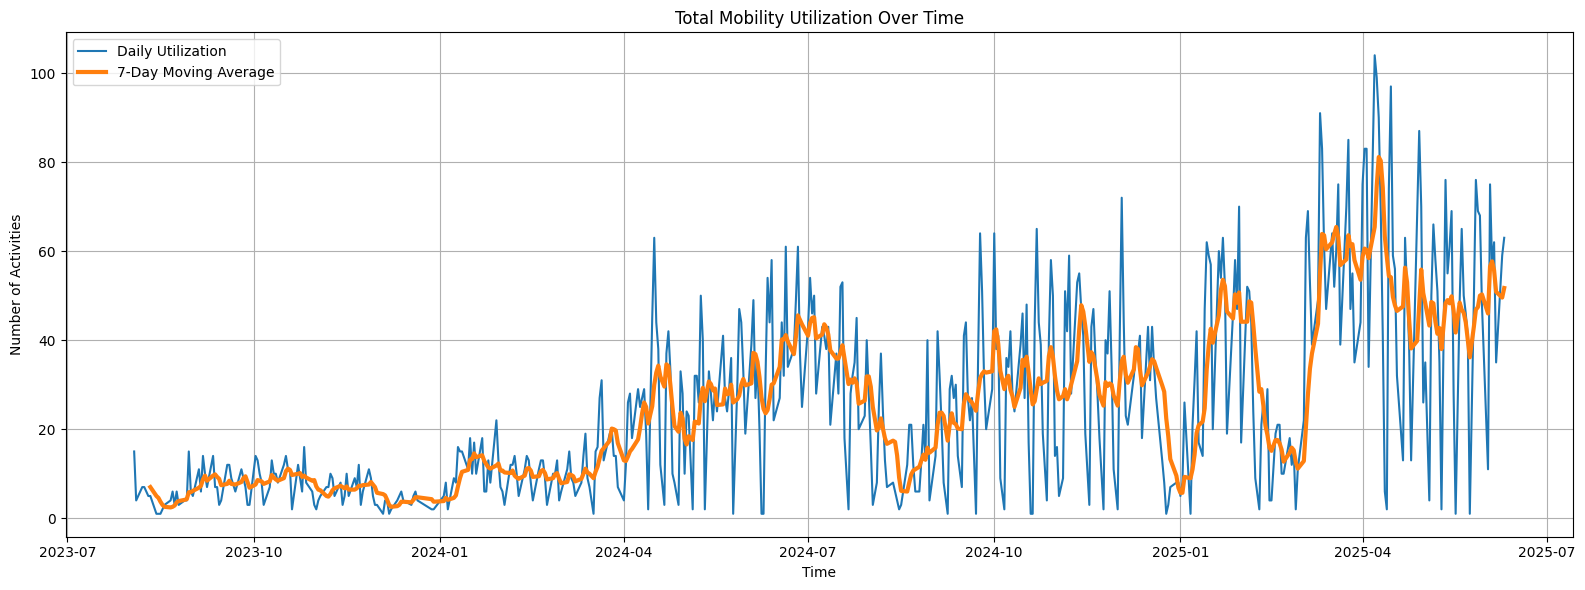

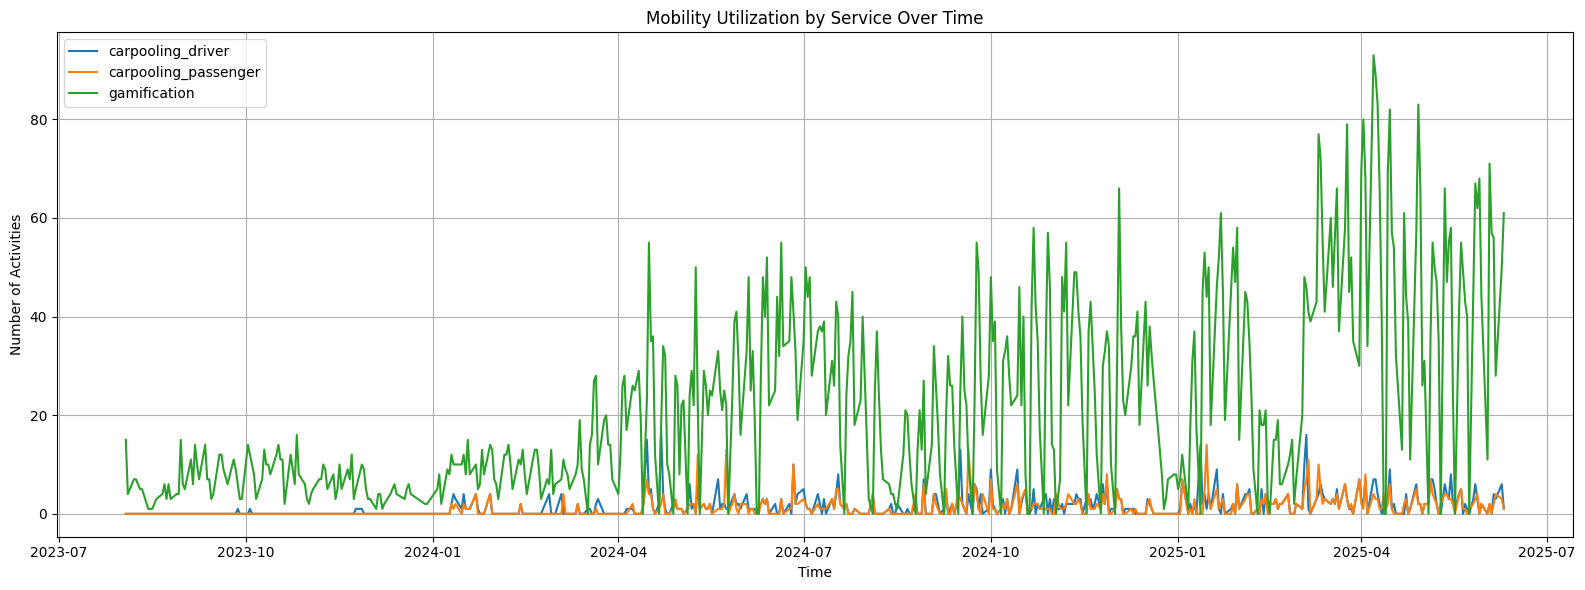

Plots generated successfully.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD CSV FILES
# ============================================================

gamification = pd.read_csv(r"C:\Users\Ramin\source\repos\Research Repo\ModeChoiceHybrid\Fastweb\Data\activities.csv")
carpooling = pd.read_csv(r"C:\Users\Ramin\source\repos\Research Repo\ModeChoiceHybrid\Fastweb\Data\carpooling.csv")

# ============================================================
# CONVERT GAMIFICATION TIMESTAMPS
# creationTS example:
# 1674657854895
# -> Unix timestamp in milliseconds
# ============================================================

# ============================================================
# CONVERT GAMIFICATION TIMESTAMPS
# creationTS example:
# 1674657854895
# ============================================================

gamification['activity_date'] = pd.to_datetime(
    gamification['creationTS'],
    unit='ms',
    utc=True,
    errors='coerce'
)

# ============================================================
# CONVERT TO LOCAL TIMEZONE
# ============================================================

gamification['activity_date'] = gamification[
    'activity_date'
].dt.tz_convert('Europe/Rome')

# ============================================================
# FILTER DATE RANGE
# KEEP ONLY:
# 2023-08-03 -> 2025-06-10 23:59:59
# ============================================================

start_date = pd.Timestamp(
    '2023-08-03 00:00:00',
    tz='Europe/Rome'
)

end_date = pd.Timestamp(
    '2025-06-10 23:59:59',
    tz='Europe/Rome'
)

gamification = gamification[
    (gamification['activity_date'] >= start_date) &
    (gamification['activity_date'] <= end_date)
]

# ============================================================
# NORMALIZE GAMIFICATION DATA
# ============================================================

gami_df = pd.DataFrame({
    'employee_id': gamification['employeeId'],
    'activity_date': gamification['activity_date'],
    'source': 'gamification'
})

# ============================================================
# PARSE CARPOOLING DRIVER EVENTS
# Example:
# 2024-01-12 16:55:45.407 +0100
# ============================================================

drivers_df = pd.DataFrame({
    'employee_id': carpooling['employee_id'],
    'activity_date': pd.to_datetime(
        carpooling['ride_creation'],
        utc=True,
        errors='coerce'
    ),
    'source': 'carpooling_driver'
})

# ============================================================
# PARSE CARPOOLING PASSENGER EVENTS
# ============================================================

passengers_df = pd.DataFrame({
    'employee_id': carpooling['employee_id'],
    'activity_date': pd.to_datetime(
        carpooling['passenger_creation'],
        utc=True,
        errors='coerce'
    ),
    'source': 'carpooling_passenger'
})

# ============================================================
# REMOVE NULL DATES
# ============================================================

gami_df = gami_df.dropna(subset=['activity_date'])
drivers_df = drivers_df.dropna(subset=['activity_date'])
passengers_df = passengers_df.dropna(subset=['activity_date'])

# ============================================================
# MERGE DATASETS
# ============================================================

unified_df = pd.concat(
    [gami_df, drivers_df, passengers_df],
    ignore_index=True
)

# ============================================================
# FORCE DATETIME TYPE AFTER CONCAT
# ============================================================

unified_df['activity_date'] = pd.to_datetime(
    unified_df['activity_date'],
    utc=True,
    errors='coerce'
)

# ============================================================
# SORT CHRONOLOGICALLY
# ============================================================

unified_df = unified_df.sort_values('activity_date')

# ============================================================
# CONVERT TO LOCAL TIMEZONE
# ============================================================

unified_df['activity_date'] = unified_df[
    'activity_date'
].dt.tz_convert('Europe/Rome')

# ============================================================
# CREATE DATE COLUMN
# ============================================================

unified_df['date'] = unified_df['activity_date'].dt.date

# ============================================================
# SAVE UNIFIED CSV
# ============================================================

unified_df.to_csv(
    "unified_mobility_dataset.csv",
    index=False
)

print("Unified CSV saved successfully.")

# ============================================================
# TOTAL UTILIZATION OVER TIME
# ============================================================

daily_total = unified_df.groupby('date').size()

# ============================================================
# UTILIZATION BY SOURCE
# ============================================================

daily_by_source = unified_df.groupby(
    ['date', 'source']
).size().unstack(fill_value=0)

# ============================================================
# CREATE 7-DAY MOVING AVERAGE
# ============================================================

rolling_total = daily_total.rolling(window=7).mean()

# ============================================================
# PLOT TOTAL UTILIZATION
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    daily_total.index,
    daily_total.values,
    label='Daily Utilization'
)

plt.plot(
    rolling_total.index,
    rolling_total.values,
    linewidth=3,
    label='7-Day Moving Average'
)

plt.xlabel("Time")
plt.ylabel("Number of Activities")

plt.title(
    "Total Mobility Utilization Over Time"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "total_utilization_over_time.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# PLOT UTILIZATION BY SERVICE
# ============================================================

plt.figure(figsize=(16, 6))

for column in daily_by_source.columns:

    plt.plot(
        daily_by_source.index,
        daily_by_source[column],
        label=column
    )

plt.xlabel("Time")
plt.ylabel("Number of Activities")

plt.title(
    "Mobility Utilization by Service Over Time"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "utilization_by_service.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Plots generated successfully.")

Unified CSV saved successfully.


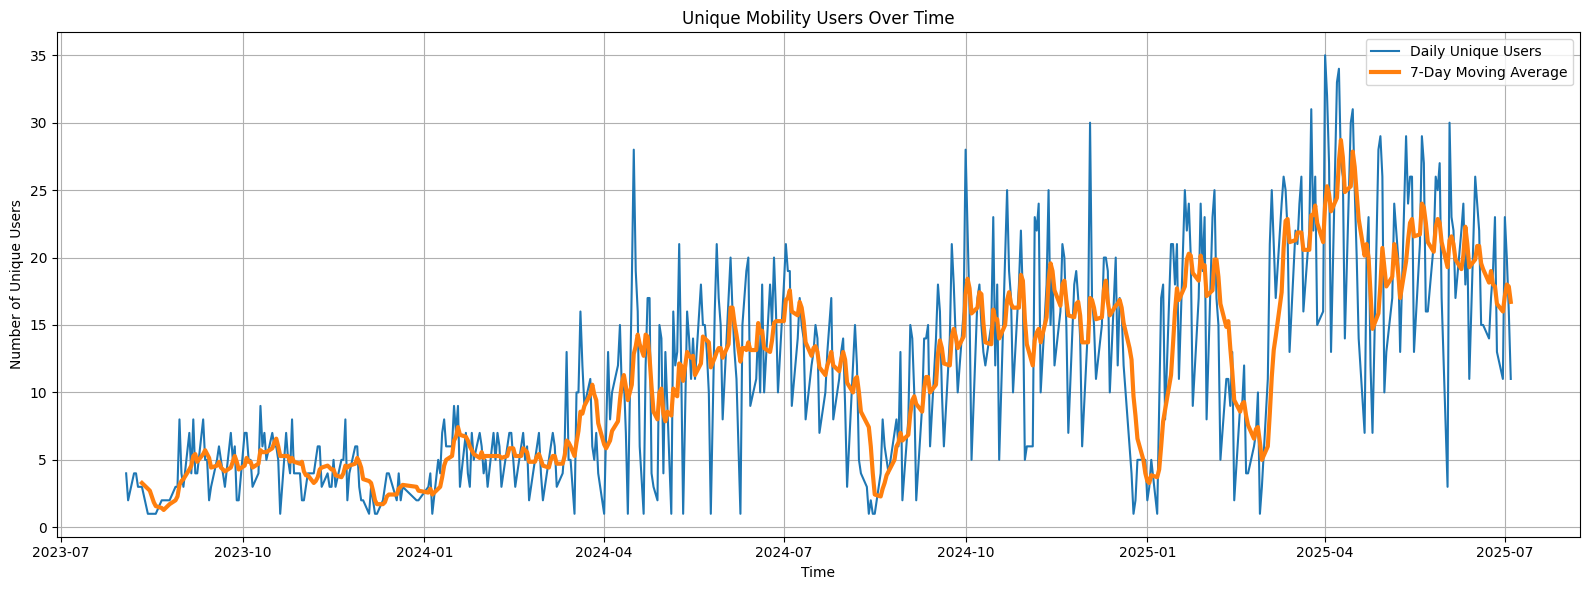

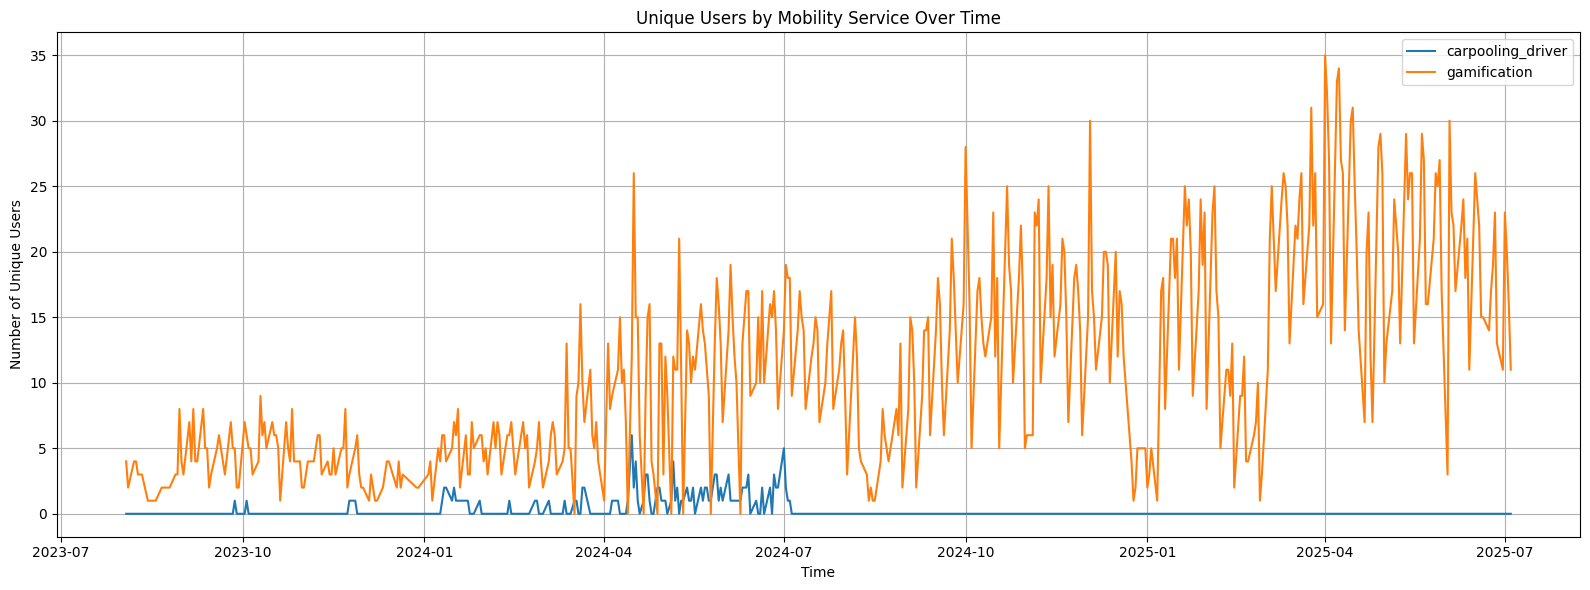

Unique user plots generated successfully.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD CSV FILES
# ============================================================

gamification = pd.read_csv(r"C:\Users\Ramin\source\repos\Research Repo\ModeChoiceHybrid\Fastweb\Data\activities.csv")
carpooling = pd.read_csv(r"C:\Users\Ramin\source\repos\Research Repo\ModeChoiceHybrid\Fastweb\Data\carpooling.csv")

# ============================================================
# CONVERT GAMIFICATION TIMESTAMPS
# creationTS example:
# 1674657854895
# -> Unix timestamp in milliseconds
# ============================================================

gamification['activity_date'] = pd.to_datetime(
    gamification['creationTS'],
    unit='ms',
    utc=True,
    errors='coerce'
)

# ============================================================
# CONVERT TO LOCAL TIMEZONE
# ============================================================

gamification['activity_date'] = gamification[
    'activity_date'
].dt.tz_convert('Europe/Rome')

# ============================================================
# FILTER GAMIFICATION DATE RANGE
# KEEP ONLY:
# 2023-08-03 -> 2025-06-10 23:59:59
# ============================================================

start_date = pd.Timestamp(
    '2023-08-03 00:00:00',
    tz='Europe/Rome'
)

end_date = pd.Timestamp(
    '2025-07-06 23:59:59',
    tz='Europe/Rome'
)

gamification = gamification[
    (gamification['activity_date'] >= start_date) &
    (gamification['activity_date'] <= end_date)
]

# ============================================================
# NORMALIZE GAMIFICATION DATA
# IMPORTANT:
# employeeId -> employee_id
# ============================================================

gami_df = pd.DataFrame({
    'employee_id': gamification['employeeId'],
    'activity_date': gamification['activity_date'],
    'source': 'gamification'
})

# ============================================================
# CREATE DRIVER EVENTS
# ============================================================

drivers_df = pd.DataFrame({
    'employee_id': carpooling['employee_id'],
    'activity_date': pd.to_datetime(
        carpooling['ride_creation'],
        utc=True,
        errors='coerce'
    ),
    'source': 'carpooling_driver'
})

# ============================================================
# CREATE PASSENGER EVENTS
# ============================================================

passengers_df = pd.DataFrame({
    'employee_id': carpooling['employee_id'],
    'activity_date': pd.to_datetime(
        carpooling['passenger_creation'],
        utc=True,
        errors='coerce'
    ),
    'source': 'carpooling_passenger'
})

# ============================================================
# REMOVE NULL DATES
# ============================================================

gami_df = gami_df.dropna(subset=['activity_date'])

drivers_df = drivers_df.dropna(
    subset=['activity_date']
)

passengers_df = passengers_df.dropna(
    subset=['activity_date']
)

# ============================================================
# MERGE ALL DATASETS
# ============================================================

unified_df = pd.concat(
    [gami_df, drivers_df, passengers_df],
    ignore_index=True
)

# ============================================================
# FORCE DATETIME TYPE
# ============================================================

unified_df['activity_date'] = pd.to_datetime(
    unified_df['activity_date'],
    utc=True,
    errors='coerce'
)

# ============================================================
# SORT CHRONOLOGICALLY
# ============================================================

unified_df = unified_df.sort_values(
    'activity_date'
)

# ============================================================
# CONVERT TO LOCAL TIMEZONE
# ============================================================

unified_df['activity_date'] = unified_df[
    'activity_date'
].dt.tz_convert('Europe/Rome')

# ============================================================
# CREATE DATE COLUMN
# ============================================================

unified_df['date'] = unified_df[
    'activity_date'
].dt.date

# ============================================================
# SAVE UNIFIED CSV
# ============================================================

unified_df.to_csv(
    "unified_mobility_dataset.csv",
    index=False
)

print("Unified CSV saved successfully.")

# ============================================================
# UNIQUE ACTIVE USERS OVER TIME
# ============================================================

daily_unique_users = unified_df.groupby(
    'date'
)['employee_id'].nunique()

# ============================================================
# UNIQUE USERS BY SERVICE
# ============================================================

daily_unique_by_source = unified_df.groupby(
    ['date', 'source']
)['employee_id'].nunique().unstack(fill_value=0)

# ============================================================
# CREATE 7-DAY MOVING AVERAGE
# ============================================================

rolling_unique = daily_unique_users.rolling(
    window=7
).mean()

# ============================================================
# PLOT TOTAL UNIQUE USERS OVER TIME
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    daily_unique_users.index,
    daily_unique_users.values,
    label='Daily Unique Users'
)

plt.plot(
    rolling_unique.index,
    rolling_unique.values,
    linewidth=3,
    label='7-Day Moving Average'
)

plt.xlabel("Time")

plt.ylabel("Number of Unique Users")

plt.title("Unique Mobility Users Over Time")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "unique_users_over_time.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# PLOT UNIQUE USERS BY SERVICE
# ============================================================

plt.figure(figsize=(16, 6))

for column in daily_unique_by_source.columns:

    plt.plot(
        daily_unique_by_source.index,
        daily_unique_by_source[column],
        label=column
    )

plt.xlabel("Time")

plt.ylabel("Number of Unique Users")

plt.title("Unique Users by Mobility Service Over Time")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "unique_users_by_service.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Unique user plots generated successfully.")